# Assignment Script

In [3]:
from collections import Counter, defaultdict
import json, os

annotators = ["harry", "celeste", "devanshi", "benjamin", "lior", "sean", "philippe", "tuhin", "connor", "kevin"]

done_counts = Counter()
assigned_counts = Counter()

sample2anno_names = defaultdict(list)

with open("data/annotations/annotator_assignment.json", "r") as f:
    annotator_assignment = json.load(f)

for annotator in annotators:
    my_done_ids = []
    if os.path.exists(f"data/annotations/{annotator}.jsonl"):
        with open(f"data/annotations/{annotator}.jsonl", "r") as f:
            for line in f:
                anno = json.loads(line)
                my_done_ids.append(anno["sample_id"])

    done_counts.update(my_done_ids)

    for my_done_id in my_done_ids:
        sample2anno_names[my_done_id].append(annotator)

    my_assignments = annotator_assignment[annotator]

    not_done_yet = [sample_id for sample_id in my_assignments if sample_id not in my_done_ids]
    for sample_id in not_done_yet:
        sample2anno_names[sample_id].append(annotator)
    assigned_counts.update(not_done_yet)

    annotator_assignment[annotator] = not_done_yet


with open("data/annotations/annotator_assignment.json", "w") as f:
    json.dump(annotator_assignment, f, indent=4)

starts = ["creative_writing_triplet", "gpt_nonfiction", "nonfiction_llama", "creative_writing_llama", "gpt_marketing"]

with open("data/preference_annotation_triplets_fixed2.jsonl", "r") as f:
    triplets = [json.loads(line) for line in f]

for triplet in triplets:
    if triplet["id"] not in done_counts:
        done_counts[triplet["id"]] = 0

sample_ids = list(set(list(assigned_counts.keys())) | set(list(done_counts.keys())))
sample_ids = sorted(sample_ids, key=lambda x: assigned_counts[x] + done_counts[x], reverse=True)

for start in starts:
    this_sample_ids = [sample_id for sample_id in sample_ids if sample_id.startswith(start)]
    print(f"============= {start} ({len(this_sample_ids)}) =============")
    for idx, sample_id in enumerate(this_sample_ids):
        print(f"{(str(idx)+'.').ljust(4)} {sample_id.ljust(35)}: {done_counts[sample_id]} done, {assigned_counts[sample_id]} assigned ({sample2anno_names[sample_id]})")



============= creative_writing_triplet (50) =============
0.   creative_writing_triplet_5         : 4 done, 0 assigned (['harry', 'celeste', 'benjamin', 'philippe'])
1.   creative_writing_triplet_7         : 4 done, 0 assigned (['harry', 'celeste', 'benjamin', 'philippe'])
2.   creative_writing_triplet_1         : 3 done, 0 assigned (['harry', 'celeste', 'philippe'])
3.   creative_writing_triplet_19        : 3 done, 0 assigned (['harry', 'devanshi', 'benjamin'])
4.   creative_writing_triplet_12        : 3 done, 0 assigned (['harry', 'devanshi', 'benjamin'])
5.   creative_writing_triplet_6         : 2 done, 1 assigned (['harry', 'celeste', 'connor'])
6.   creative_writing_triplet_8         : 3 done, 0 assigned (['harry', 'celeste', 'philippe'])
7.   creative_writing_triplet_9         : 3 done, 0 assigned (['harry', 'celeste', 'philippe'])
8.   creative_writing_triplet_2         : 3 done, 0 assigned (['harry', 'celeste', 'philippe'])
9.   creative_writing_triplet_11        : 3 done, 0 as

# Main Results

In [10]:
import json, numpy as np

triplet_types = ["gpt_creative_writing", "llama_creative_writing", "gpt_nonfiction", "llama_nonfiction", "marketing_gpt"]

with open("data/preference_annotation_triplets_fixed2.jsonl", "r") as f:
    triplets = [json.loads(line) for line in f]

for annotator in ["sean", "harry", "celeste", "devanshi", "benjamin", "lior", "philippe", "tuhin", "connor"]:
    anno_fn = f"data/annotations/{annotator}.jsonl"

    annotations = []
    with open(anno_fn, "r") as f:
        for line in f:
            anno = json.loads(line)
            annotations.append(anno)

    print("=============================")
    print(f"Annotator {annotator} has completed {len(annotations)} triplets")

    for triplet_type in triplet_types:
        triplet_ids = [d['id'] for d in triplets if d['triplet_type'] == triplet_type]
        this_annotations = [a for a in annotations if a['sample_id'] in triplet_ids]
        if len(this_annotations) == 0:
            continue

        text2rank = {"Most Preferred Writing Option": 1, "Second Favorite Writing Option": 2, "Least Preferred Writing Option": 3}
        system_names = ["best_cot", "random_cot", "first_draft"]
        ranks = {system_name: [] for system_name in system_names}
        for anno in this_annotations:
            for system_name in system_names:
                ranks[system_name].append(text2rank[anno["rankings"][system_name]])
        print("--------------------------------")
        print(f"Triplet Type: {triplet_type} (N={len(this_annotations)})")
        for system_name in sorted(system_names, key=lambda x: np.mean(ranks[x])):
            print(f"   {system_name.ljust(15)}: {np.mean(ranks[system_name]):.2f} ({np.std(ranks[system_name]):.2f}) ({ranks[system_name]})")



Annotator sean has completed 10 triplets
--------------------------------
Triplet Type: gpt_nonfiction (N=5)
   first_draft    : 1.80 (0.75) ([1, 3, 2, 1, 2])
   best_cot       : 2.00 (0.89) ([3, 1, 1, 2, 3])
   random_cot     : 2.20 (0.75) ([2, 2, 3, 3, 1])
--------------------------------
Triplet Type: llama_nonfiction (N=5)
   random_cot     : 1.80 (0.75) ([2, 1, 1, 2, 3])
   best_cot       : 2.00 (0.89) ([1, 3, 3, 1, 2])
   first_draft    : 2.20 (0.75) ([3, 2, 2, 3, 1])
Annotator harry has completed 30 triplets
--------------------------------
Triplet Type: gpt_creative_writing (N=20)
   best_cot       : 1.50 (0.74) ([1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 3, 3, 1, 3, 1, 2, 1, 1, 1])
   first_draft    : 2.15 (0.65) ([2, 3, 2, 3, 2, 1, 3, 1, 2, 2, 3, 1, 2, 2, 2, 3, 3, 2, 2, 2])
   random_cot     : 2.35 (0.79) ([3, 2, 3, 1, 3, 3, 2, 3, 3, 3, 2, 2, 1, 3, 1, 2, 1, 3, 3, 3])
--------------------------------
Triplet Type: gpt_nonfiction (N=5)
   first_draft    : 1.80 (0.75) ([2, 1, 3, 1, 2])
 

In [11]:
import json, numpy as np

triplet_types = ["gpt_creative_writing", "llama_creative_writing", "gpt_nonfiction", "llama_nonfiction"]

with open("data/preference_annotation_triplets_fixed2.jsonl", "r") as f:
    triplets = [json.loads(line) for line in f]

anno_id2triplet = {d['id']: d for d in triplets}

annotations = {}

text2rank = {"Most Preferred Writing Option": 1, "Second Favorite Writing Option": 2, "Least Preferred Writing Option": 3}
system_names = ["best_cot", "random_cot", "first_draft"]

for annotator in ["harry", "celeste", "devanshi", "benjamin", "lior", "philippe", "tuhin", "connor", "sean"]: # , "sean", "philippe", "tuhin", "connor"
    this_annotations = []
    with open(f"data/annotations/{annotator}.jsonl", "r") as f:
        for line in f:
            this_annotations.append(json.loads(line))

    for anno in this_annotations:
        triplet = anno_id2triplet[anno["sample_id"]]
        triplet_type = triplet["triplet_type"]
        if triplet_type not in annotations:
            annotations[triplet_type] = []

        system_rank_map = {system_name: text2rank[anno["rankings"][system_name]] for system_name in system_names}
        # print(system_rank_map, anno["rankings"])
        annotations[triplet_type].append(system_rank_map)

# add overall
triplet_types = list(annotations.keys())
annotations["overall"] = []
for triplet_type in triplet_types:
    annotations["overall"] += annotations[triplet_type]

for triplet_type in annotations:
    print(f"============ {triplet_type.upper()} ({len(annotations[triplet_type])}) =============")
    system_name2rank = {system_name: np.mean([r[system_name] for r in annotations[triplet_type]]) for system_name in system_names}
    for system_name in sorted(system_names, key=lambda x: system_name2rank[x]):
        print(f"   {system_name.ljust(15)}: {np.mean([r[system_name] for r in annotations[triplet_type]]):.2f} ({np.std([r[system_name] for r in annotations[triplet_type]]):.2f})")

============ GPT_CREATIVE_WRITING (58) =============
   best_cot       : 1.59 (0.74)
   random_cot     : 2.05 (0.80)
   first_draft    : 2.36 (0.71)
============ LLAMA_NONFICTION (36) =============
   first_draft    : 1.92 (0.76)
   best_cot       : 1.94 (0.88)
   random_cot     : 2.14 (0.79)
============ GPT_NONFICTION (22) =============
   best_cot       : 1.86 (0.87)
   random_cot     : 2.05 (0.77)
   first_draft    : 2.09 (0.79)
============ LLAMA_CREATIVE_WRITING (23) =============
   best_cot       : 1.78 (0.83)
   random_cot     : 1.91 (0.72)
   first_draft    : 2.30 (0.80)
============ MARKETING_GPT (28) =============
   best_cot       : 1.50 (0.73)
   random_cot     : 1.86 (0.64)
   first_draft    : 2.64 (0.61)
============ OVERALL (167) =============
   best_cot       : 1.71 (0.82)
   random_cot     : 2.02 (0.76)
   first_draft    : 2.27 (0.77)


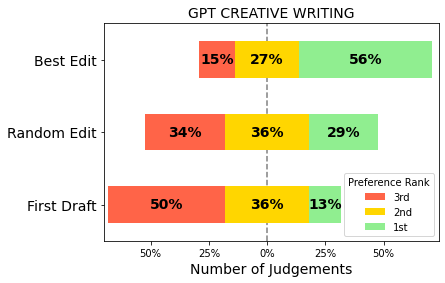

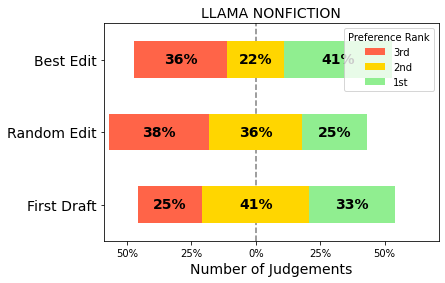

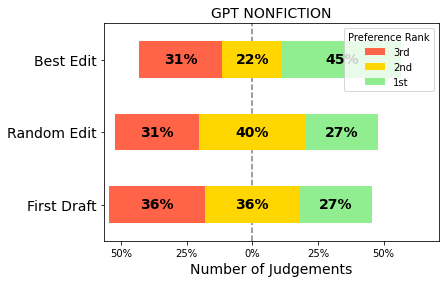

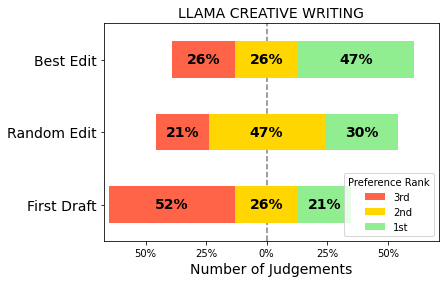

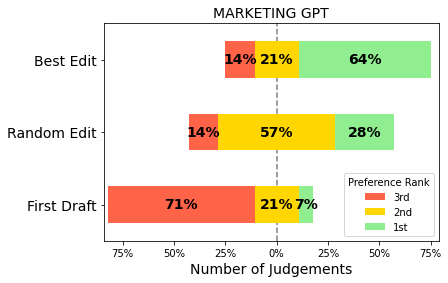

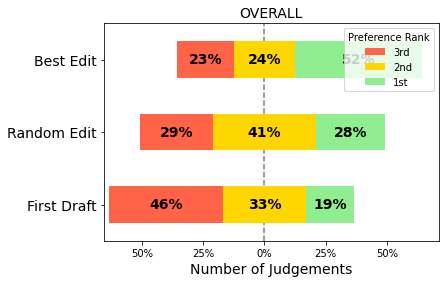

In [12]:
from matplotlib import pyplot as plt
import pandas as pd, plot_likert

idx2rank = {1: "1st", 2: "2nd", 3: "3rd"}
scale = ["3rd", "2nd", "1st"]
colors = ["#ffffff00", "#ff6448", "#ffd600", "#90ee90"]
clean_system_name = {"best_cot": "Best Edit", "random_cot": "Random Edit", "first_draft": "First Draft"}

for triplet_idx, triplet_type in enumerate(annotations):
    data = pd.DataFrame({clean_system_name[system_name]: {i: idx2rank[r[system_name]] for i, r in enumerate(annotations[triplet_type])} for system_name in system_names})
    ax = plot_likert.plot_likert(data, scale, colors=colors, bar_labels=True, plot_percentage=True, bar_labels_color="black", xtick_interval=25)
    ax.legend(title="Preference Rank")
    ax.set_xlabel("Number of Judgements", fontsize=14)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
    plt.title(triplet_type.replace("_", " ").upper(), fontsize=14)
    plt.show()

In [3]:
import json, numpy as np, itertools, pandas as pd

triplet_types = ["gpt_creative_writing", "llama_creative_writing", "gpt_nonfiction", "llama_nonfiction"]

def gap2bin(gap, bin_width=0.5):
    # if 0.7, need to return "0.5-1.0"
    # if 0.2, need to return "0.0-0.5"
    min = 0.0
    while gap > min:
        min += bin_width
    return f"{min-bin_width}-{min}"

with open("data/preference_annotation_triplets_fixed2.jsonl", "r") as f:
    triplets = [json.loads(line) for line in f]

anno_id2triplet = {d['id']: d for d in triplets}

pairwise_gaps = {}

text2rank = {"Most Preferred Writing Option": 1, "Second Favorite Writing Option": 2, "Least Preferred Writing Option": 3}
system_names = ["best_cot", "random_cot", "first_draft"]
# system_names = ["best_cot", "first_draft"]

for annotator in ["harry", "celeste", "devanshi", "benjamin", "lior", "philippe", "tuhin", "connor", "sean"]:
    this_annotations = []
    with open(f"data/annotations/{annotator}.jsonl", "r") as f:
        for line in f:
            this_annotations.append(json.loads(line))

    for anno in this_annotations:
        triplet = anno_id2triplet[anno["sample_id"]]
        system2score = {system_name: triplet[system_name]["score"] for system_name in system_names}
        system2rank = {system_name: text2rank[anno["rankings"][system_name]] for system_name in system_names}

        for s1, s2 in itertools.combinations(system_names, 2):
            gap = system2score[s1] - system2score[s2]
            if gap <= 0.0:
                print("This shouldn't happen too much")
                continue
            bin = gap2bin(gap, bin_width=0.5)
            agreement = 1 if (system2rank[s1] - system2rank[s2]) * (system2score[s1] - system2score[s2]) < 0 else 0
            if bin not in pairwise_gaps:
                pairwise_gaps[bin] = []
            pairwise_gaps[bin].append(agreement)

bins = sorted(pairwise_gaps.keys())
results = []
for bin in bins:
    result_row = {"bin": bin, "count": len(pairwise_gaps[bin]), "agreement": np.mean(pairwise_gaps[bin])}
    results.append(result_row)

pd.DataFrame(results)

This shouldn't happen too much
This shouldn't happen too much
This shouldn't happen too much
This shouldn't happen too much


,bin,count,agreement
0,0.0-0.5,68,0.617647
1,0.5-1.0,123,0.626016
2,1.0-1.5,113,0.628319
3,1.5-2.0,85,0.647059
4,2.0-2.5,56,0.571429
5,2.5-3.0,19,0.631579
6,3.0-3.5,17,0.705882
7,3.5-4.0,4,1.000000


# Inter-Annotator Agreement

In [5]:
from scipy.stats import kendalltau
import itertools, numpy as np

def get_annotations(annotator):
    anno_fn = f"data/annotations/{annotator}.jsonl"
    annotations = []
    with open(anno_fn, "r") as f:
        for line in f:
            anno = json.loads(line)
            annotations.append(anno)
    return annotations

annotators = ["harry", "celeste", "devanshi", "benjamin", "lior", "philippe", "tuhin", "connor", "sean"]
system_names = ["best_cot", "random_cot", "first_draft"]
text2rank = {"Most Preferred Writing Option": 1, "Second Favorite Writing Option": 2, "Least Preferred Writing Option": 3}

kendalls = []
for a1, a2 in itertools.combinations(annotators, 2):
    annos1 = get_annotations(a1)
    annos2 = get_annotations(a2)

    annoid1_2anno = {a["sample_id"]: a for a in annos1}
    annoid2_2anno = {a["sample_id"]: a for a in annos2}

    common_anno_ids = set([a["sample_id"] for a in annos1]) & set([a["sample_id"] for a in annos2])

    for anno_id in common_anno_ids:
        anno1_rankings = annoid1_2anno[anno_id]["rankings"]
        anno2_rankings = annoid2_2anno[anno_id]["rankings"]

        ordered_ranks1 = [text2rank[anno1_rankings[system_name]] for system_name in system_names]
        ordered_ranks2 = [text2rank[anno2_rankings[system_name]] for system_name in system_names]

        # print("=============")
        # print(anno_id)
        # print(a1, ordered_ranks1)  # [1, 2, 3]
        # print(a2, ordered_ranks2)  # [1, 2, 3]
        tau, p_value = kendalltau(ordered_ranks1, ordered_ranks2)
        # print(f"Kendall's tau: {tau}")
        kendalls.append(tau)

print(f"Average Kendall's tau: {np.mean(kendalls)}")


Average Kendall's tau: 0.06666666666666667
